# **CSE437 Project**

# **Import Libraries & Load Dataset**

In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dataset = 'https://drive.google.com/uc?export=download&id=1dpbXDZ0UreOc-0jJMWtmA8oykR1I-Opn'

# Load the dataset directly from the URL
df = pd.read_csv(dataset)

# Display the first few rows
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4240, 16)


,gender,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,Heart Disease (in next 10 years)
0,Male,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,Female,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,Male,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,Female,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,Female,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


# **Distribution of Output Class**

Class distribution of HeartDisease:
HeartDisease
0    3596
1     644
Name: count, dtype: int64


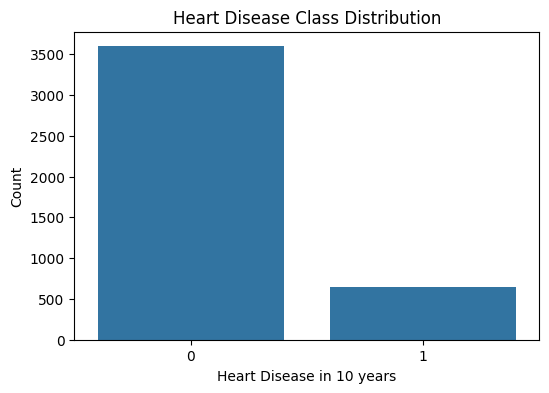


Shape of the dataset: (4240, 16)


In [197]:
import matplotlib.pyplot as plt
import seaborn as sns

df.rename(columns={'Heart Disease (in next 10 years)': 'HeartDisease'}, inplace=True) # for easy coding / remember to check its maintained
print("Class distribution of HeartDisease:")
print(df['HeartDisease'].value_counts())


plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='HeartDisease')
plt.title("Heart Disease Class Distribution")
plt.xlabel("Heart Disease in 10 years")
plt.ylabel("Count")
plt.show()
print("\nShape of the dataset:", df.shape)

# **Histogram of Numeric Features**

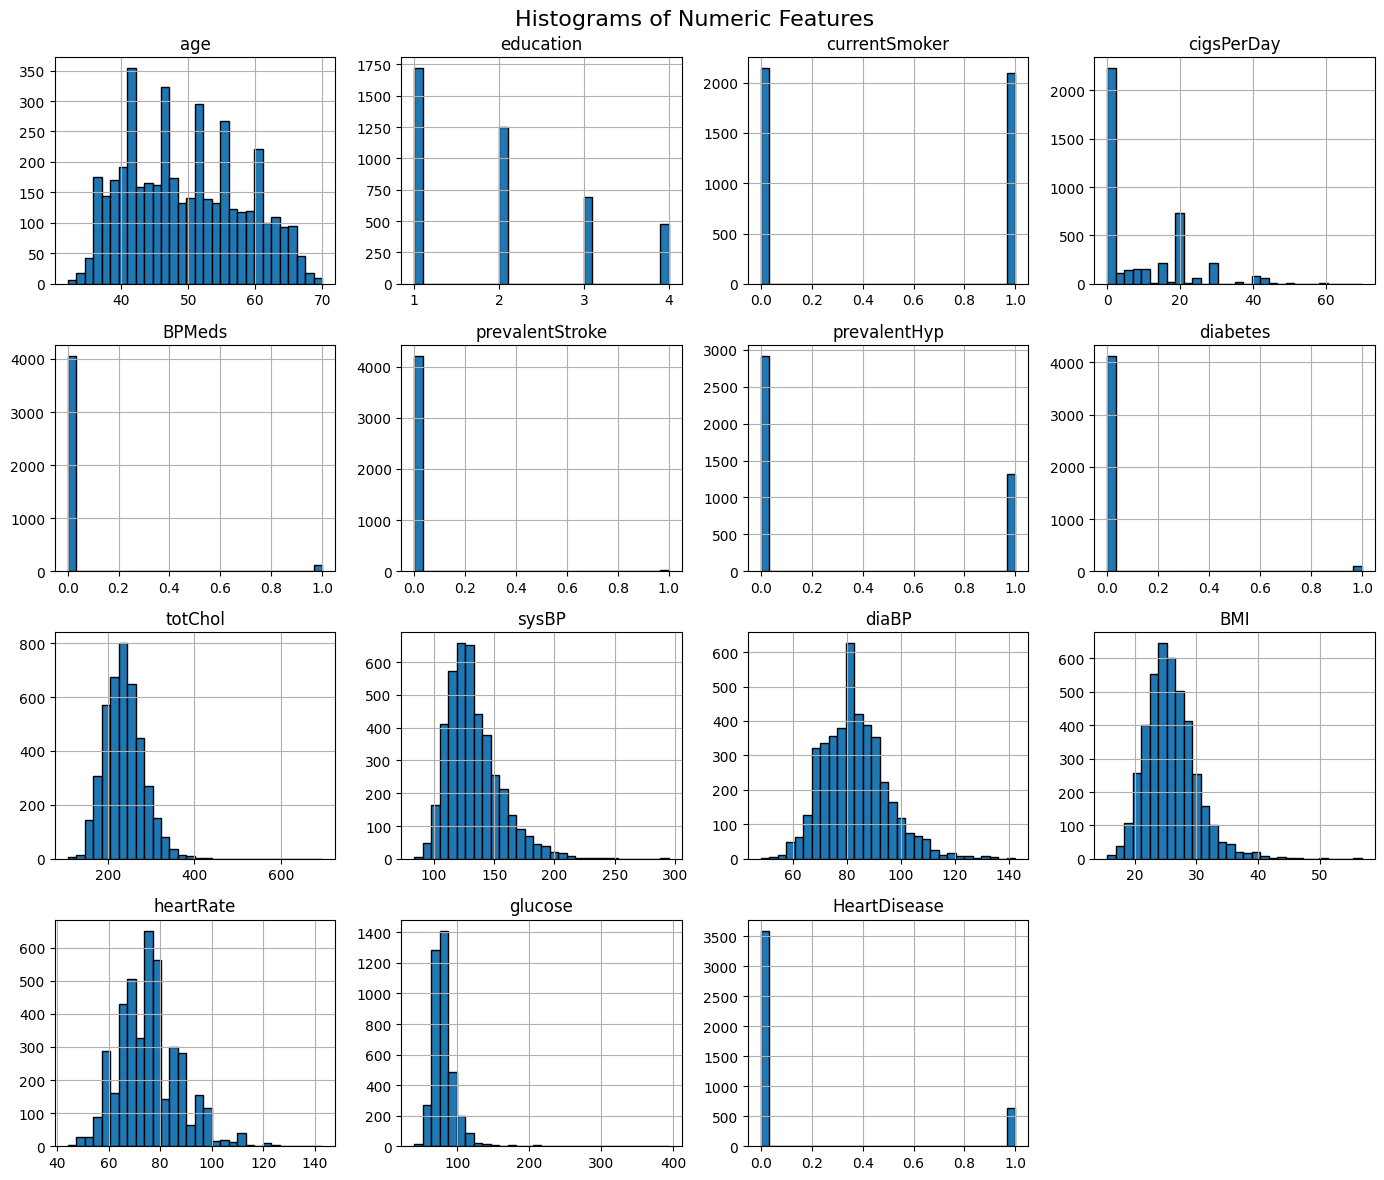

In [198]:
df.hist(bins=30, figsize=(14, 12), edgecolor='black')
plt.suptitle("Histograms of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

# **Categorical Feature (Gender)**

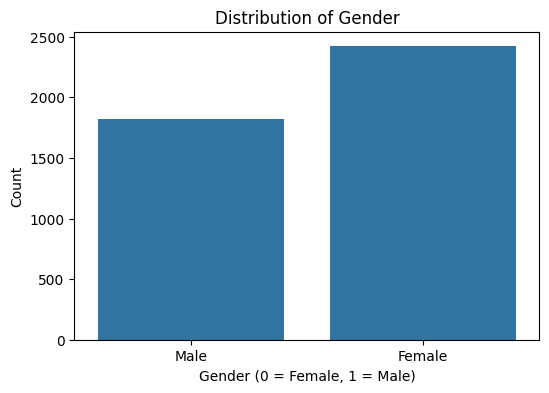

In [199]:
# Count plot for gender
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='gender')
plt.title('Distribution of Gender')
plt.xlabel('Gender (0 = Female, 1 = Male)')
plt.ylabel('Count')
plt.show()

# **Box Plot**

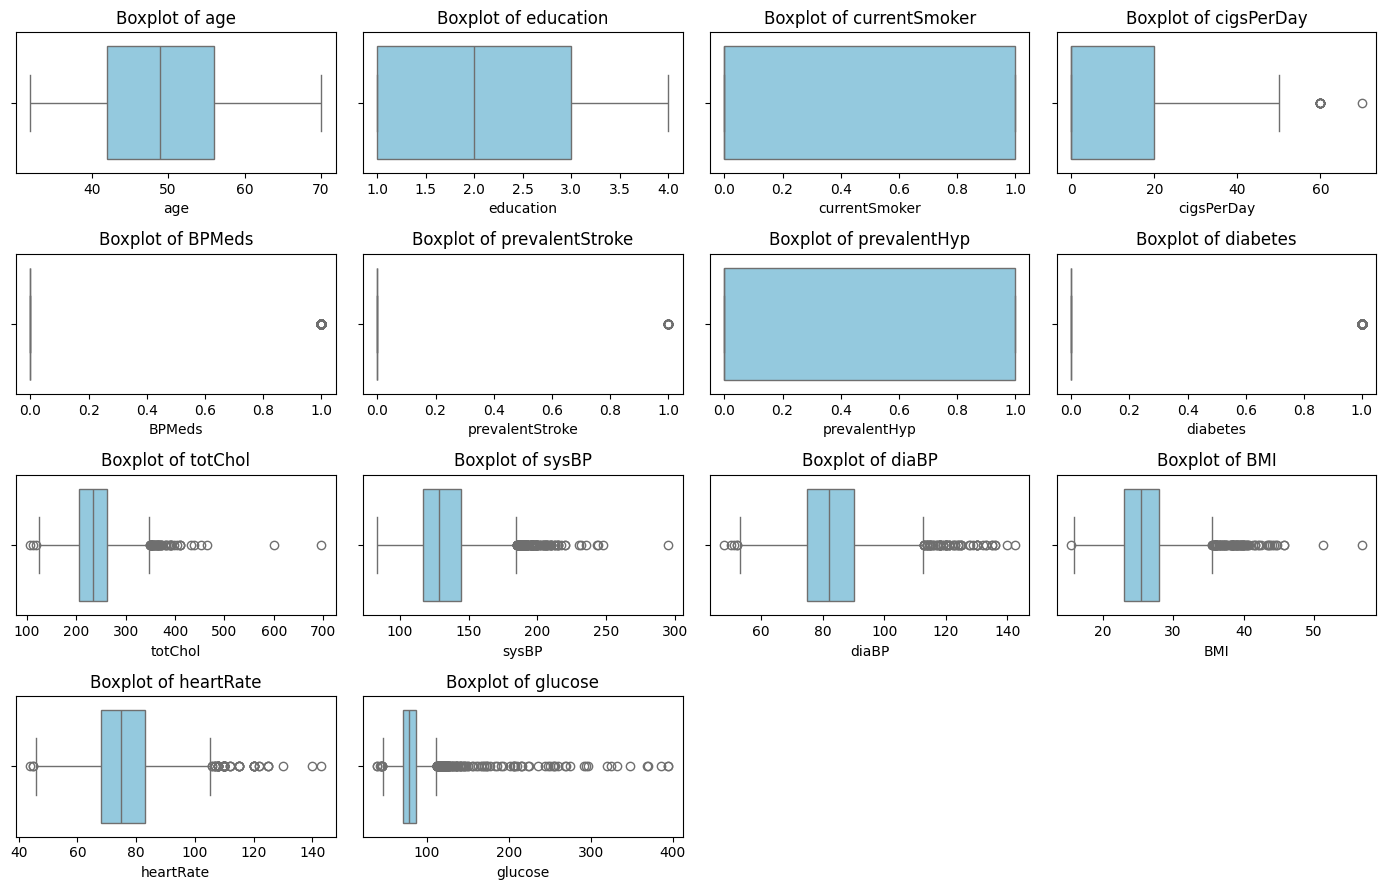

In [200]:
plt.figure(figsize=(14, 9))
numeric_columns = df.select_dtypes(include=np.number).columns.drop('HeartDisease')

for i, column in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(data=df, x=column, color='skyblue')
    plt.title(f"Boxplot of {column}")
plt.tight_layout()
plt.show()

# **Handle Missing Values and Remove Duplicates**

In [201]:
print("Null values in each column:")
print(df.isnull().sum())
duplicates = df[df.duplicated()]
print("\nNumber of duplicate rows:", len(duplicates))
df = df.drop_duplicates()
print("\nShape after dropping duplicates:", df.shape)

Null values in each column:
gender               0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
HeartDisease         0
dtype: int64

Number of duplicate rows: 0

Shape after dropping duplicates: (4240, 16)


**Handle Missing Values**

In [202]:
num_cols = ['cigsPerDay', 'education', 'BPMeds', 'totChol', 'BMI', 'heartRate', 'glucose']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
gender             0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
HeartDisease       0
dtype: int64


# **Encode Categorical Variable**

In [203]:
df_encoded = df.copy()
df_encoded['gender'] = df_encoded['gender'].map({'Male': 1, 'Female': 0})
df_encoded.head(10)

,gender,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,HeartDisease
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,2.0,0,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
6,0,63,1.0,0,0.0,0.0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1
7,0,45,2.0,1,20.0,0.0,0,0,0,313.0,100.0,71.0,21.68,79.0,78.0,0
8,1,52,1.0,0,0.0,0.0,0,1,0,260.0,141.5,89.0,26.36,76.0,79.0,0
9,1,43,1.0,1,30.0,0.0,0,1,0,225.0,162.0,107.0,23.61,93.0,88.0,0


# **Correlation Heatmap (to check feature relationships)**

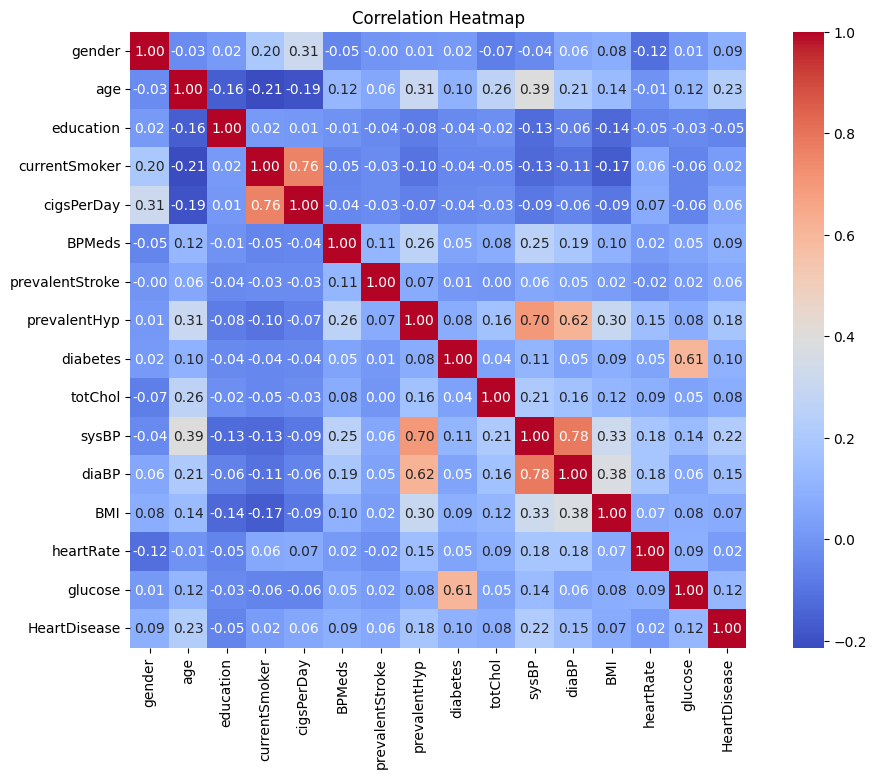

In [204]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

# Calculate correlation
correlation = df_encoded.corr()

# Plot heatmap
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Heatmap')
plt.show()

# **Split the Data (Train-Test Split)** & **Dropping weak feature**

In [205]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(['HeartDisease', 'education'], axis=1)
y = df_encoded['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #test_size=0.3

total_samples = X.shape[0]
train_samples = X_train.shape[0]
test_samples = X_test.shape[0]
split_ratio = test_samples / total_samples

print(f"Total samples: {total_samples}")
print(f"Training set: {train_samples} samples ({train_samples / total_samples:.2%})")
print(f"Testing set: {test_samples} samples ({split_ratio:.2%})")


Total samples: 4240
Training set: 3392 samples (80.00%)
Testing set: 848 samples (20.00%)


# **Feature Scaling**

In [206]:
from sklearn.preprocessing import MinMaxScaler

numerical_columns = df_encoded.select_dtypes(include=[np.number]).columns.drop('HeartDisease')

scaler = MinMaxScaler()
df_encoded[numerical_columns] = scaler.fit_transform(df_encoded[numerical_columns])

print("Feature scaling completed. Here are the first few rows after scaling:")
df_encoded.head(10)

Feature scaling completed. Here are the first few rows after scaling:


,gender,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,HeartDisease
0,1.0,0.184211,1.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.149406,0.106383,0.232804,0.277024,0.363636,0.104520,0
1,0.0,0.368421,0.333333,0.0,0.000000,0.0,0.0,0.0,0.0,0.242784,0.177305,0.349206,0.319680,0.515152,0.101695,0
2,1.0,0.421053,0.000000,1.0,0.285714,0.0,0.0,0.0,0.0,0.234295,0.208038,0.338624,0.237518,0.313131,0.084746,0
3,0.0,0.763158,0.666667,1.0,0.428571,0.0,0.0,1.0,0.0,0.200340,0.314421,0.497354,0.316045,0.212121,0.177966,1
4,0.0,0.368421,0.666667,1.0,0.328571,0.0,0.0,0.0,0.0,0.302207,0.219858,0.380952,0.183228,0.414141,0.127119,0
5,0.0,0.289474,0.333333,0.0,0.000000,0.0,0.0,1.0,0.0,0.205433,0.456265,0.656085,0.357731,0.333333,0.166667,0
6,0.0,0.815789,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.166384,0.257683,0.243386,0.425836,0.161616,0.127119,1
7,0.0,0.342105,0.333333,1.0,0.285714,0.0,0.0,0.0,0.0,0.349745,0.078014,0.243386,0.148812,0.353535,0.107345,0
8,1.0,0.526316,0.000000,0.0,0.000000,0.0,0.0,1.0,0.0,0.259762,0.274232,0.433862,0.262239,0.323232,0.110169,0
9,1.0,0.289474,0.000000,1.0,0.428571,0.0,0.0,1.0,0.0,0.200340,0.371158,0.624339,0.195589,0.494949,0.135593,0


# **Model Training (Decision Tree, KNN, Naive Bayes, Logistic Regression, MLP Classifier)**

In [207]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=5000),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Neural Network': MLPClassifier(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}


for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} model trained successfully.")


Logistic Regression model trained successfully.
KNN model trained successfully.
Naive Bayes model trained successfully.
Neural Network model trained successfully.
Decision Tree model trained successfully.


# **EVALUATION**

In [208]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

results = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'AUC': [],
}

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    results['Model'].append(model_name)
    results['Accuracy'].append(accuracy)
    results['Precision'].append(precision)
    results['Recall'].append(recall)
    results['F1 Score'].append(f1)
    results['AUC'].append(auc)

import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)


                 Model  Accuracy  Precision    Recall  F1 Score       AUC
0  Logistic Regression  0.857311   0.562500  0.073171  0.129496  0.709010
1                  KNN  0.844340   0.354839  0.089431  0.142857  0.587177
2          Naive Bayes  0.830189   0.327869  0.162602  0.217391  0.704250
3       Neural Network  0.853774   0.428571  0.024390  0.046154  0.617740
4        Decision Tree  0.764151   0.218978  0.243902  0.230769  0.548158


# **Bar Chart for Accuracy, Precision, recall comparison of all models**

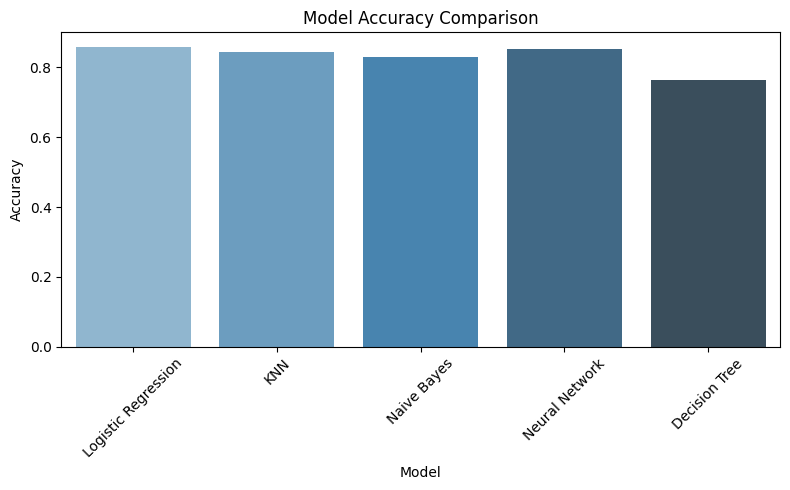

In [209]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='Model', y='Accuracy', hue='Model', palette='Blues_d', legend=False)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Precision, Recall, F1 Score**

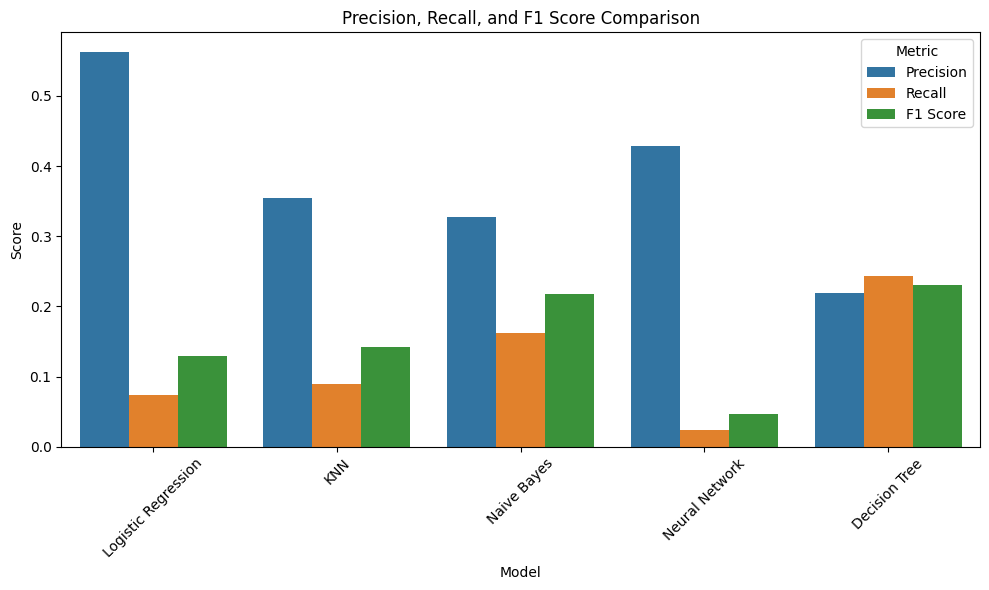

In [210]:
metrics_df = results_df.melt(id_vars='Model',
                             value_vars=['Precision', 'Recall', 'F1 Score'],
                             var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_df, x='Model', y='Score', hue='Metric')
plt.title('Precision, Recall, and F1 Score Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()


# **Confusion Matrix**

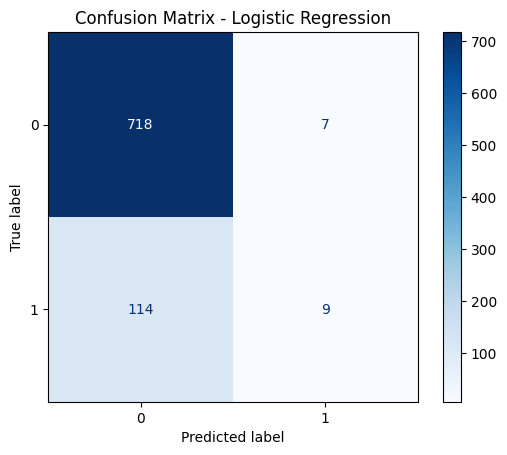

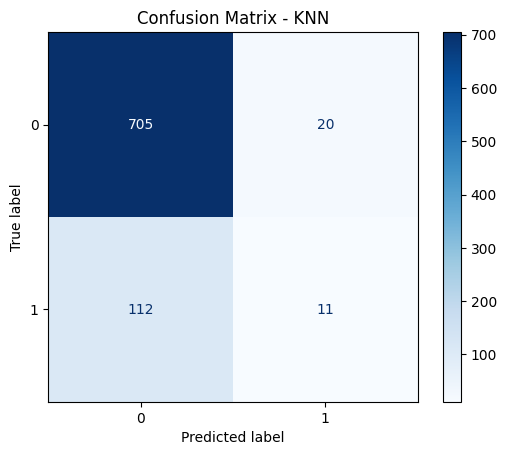

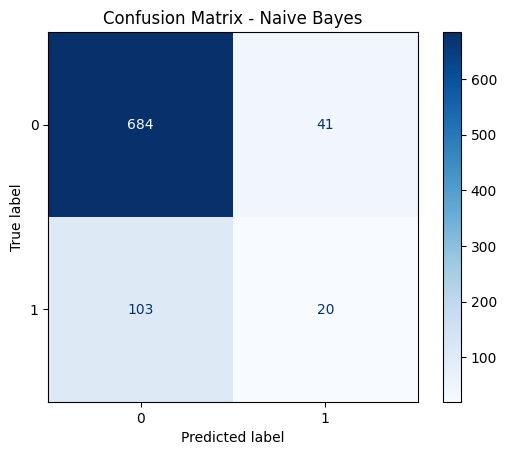

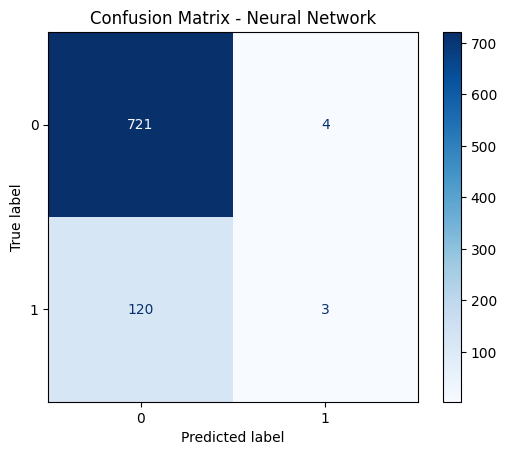

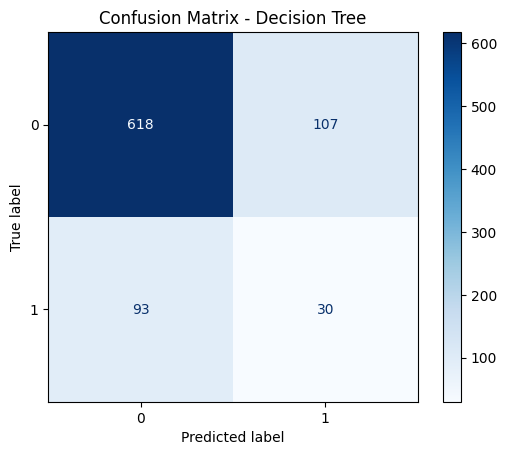

In [211]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
for model_name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred) #Computing confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()


# **ROC Curves**

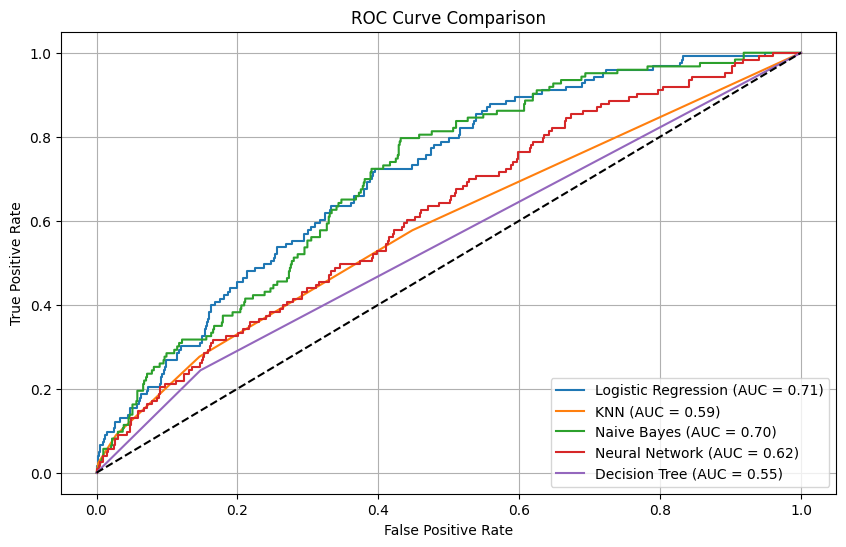

In [212]:
from sklearn.metrics import roc_curve
plt.figure(figsize=(10,6))
for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid()
plt.show()